**🌐 Language:** **English** | [한국어 →](/rdd-basic-ko)

# Regression Discontinuity Design (RDD)

<small><em>Written by Jiwoo Son · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## 1. What is RDD?

The college entrance exam results are in. The scholarship cutoff is 70 points. A student who scored 69 and a student who scored 71 are just 2 points apart — a difference that likely reflects the luck of the day more than any meaningful gap in ability. Yet one receives a scholarship and the other does not.

Now flip the question. If we want to estimate the causal effect of the scholarship on academic achievement, who is the ideal comparison group? Exactly these two students. Those just above and just below the cutoff are essentially equivalent in every way except for whether they received the scholarship.

This is the core idea of **RDD (Regression Discontinuity Design)**.

When treatment (a policy, benefit, etc.) is assigned based on whether a continuous variable crosses a specific threshold (cutoff), we compare units just on either side of that threshold to estimate the causal effect. Unlike RCT, there is no random assignment — but near the cutoff, the situation closely approximates one.

RDD applies in more real-world settings than you might expect.

| Setting | Running Variable | Cutoff | Treatment |
|---------|-----------------|--------|-----------|
| Scholarship eligibility | Exam score | 70 points | Scholarship award |
| Welfare benefit eligibility | Income level | 50% of median income | Cash transfer |
| Legal drinking age | Age | 19 years old | Alcohol purchase allowed |
| Drug insurance coverage | Drug price | Specific price threshold | Insurance reimbursement |

Wherever a clear rule determines treatment, RDD is worth considering.

## 2. Types of RDD

RDD comes in two main variants: Sharp Design and Fuzzy Design.

* `Sharp Design`: treatment is fully determined by whether the running variable crosses the cutoff.
* `Fuzzy Design`: the cutoff affects the probability of treatment, but does not perfectly determine it.

For example, if every student who scores above 70 is guaranteed a scholarship, that’s Sharp. If some eligible students don’t apply or fail a secondary review, that’s Fuzzy. This chapter focuses on Sharp RDD; Fuzzy RDD is covered in a separate chapter.

In [30]:
def plot_rdd_type():
    c = 0
    R = np.linspace(-3, 3, 300)
    
    D_sharp = np.where(R >= c, 1.0, 0.0)
    
    D_fuzzy = np.where(R >= c,
                       0.65 + 0.1 * np.tanh(R * 2),
                       0.15 + 0.1 * np.tanh(R * 2))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ── Sharp RDD ──
    ax = axes[0]
    ax.plot(R[R <  c], D_sharp[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_sharp[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    ax.scatter([c], [0], s=80, color='tomato', zorder=5, edgecolors='tomato', facecolors='none', linewidths=2)
    ax.scatter([c], [1], s=80, zorder=5)
    ax.annotate('', xy=(c, 1.0), xytext=(c, 0.0),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, 0.5, '0 → 1\n(perfect jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Sharp RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── Fuzzy RDD ──
    ax = axes[1]
    ax.plot(R[R <  c], D_fuzzy[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_fuzzy[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    
    d_l = np.interp(c - 0.009, R, D_fuzzy)
    d_r = np.interp(c + 0.009, R, D_fuzzy)
    ax.scatter([c], [d_l], s=80, color='tomato', zorder=5, facecolors='none', edgecolors='tomato', linewidths=2)
    ax.scatter([c], [d_r], s=80, zorder=5)
    ax.annotate('', xy=(c, d_r), xytext=(c, d_l),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, (d_l + d_r) / 2,
            f'{d_l:.2f} → {d_r:.2f}\n(partial jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Fuzzy RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.suptitle(r'Sharp vs Fuzzy RDD — $P(D=1 \mid R)$', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

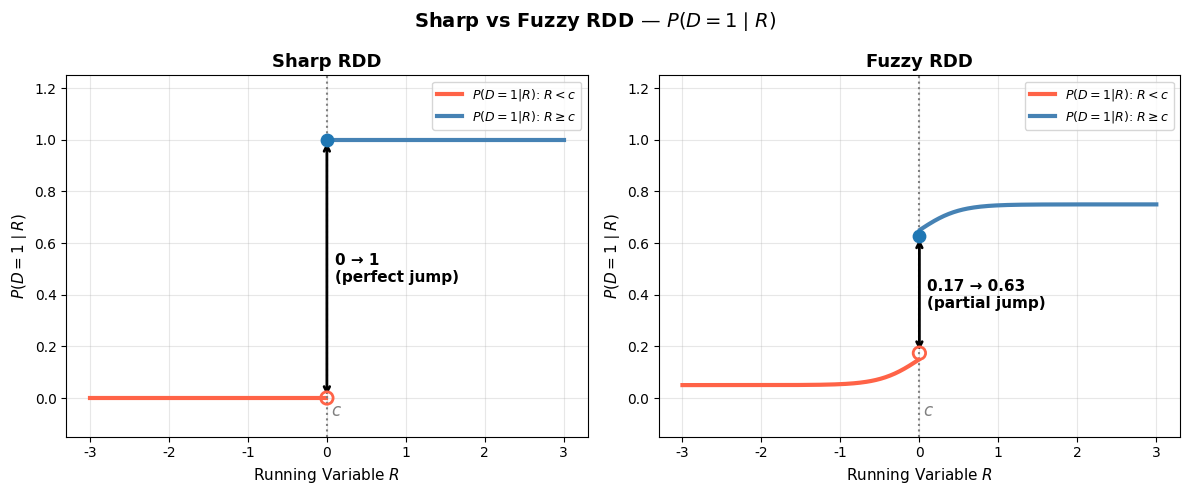

In [31]:
plot_rdd_type()

## 3. Key Assumptions

For RDD to produce valid causal estimates, two important assumptions must hold.

### Continuity Assumption

The first is **continuity of potential outcomes**. Both the expected GPA without the scholarship and the expected GPA with it must vary smoothly near the cutoff — no sudden jumps.

$$\mathbb{E}[Y_i(0) \mid X_i = x] \quad \text{and} \quad \mathbb{E}[Y_i(1) \mid X_i = x] \quad \text{are continuous at } x = c$$

Why does this matter? If this holds, then any **sharp discontinuity** in observed outcomes near the cutoff can only be attributed to the treatment (the scholarship).

What if this assumption breaks down? For instance, if the school provides extra tutoring specifically to students near the 70-point threshold, then a jump in GPA near the cutoff could be due to the tutoring — not the scholarship — and we can no longer identify the causal effect.

### Local Randomization

The second assumption is another way of expressing continuity. Very close to the cutoff $c$, whether a student scores 69.5 or 70.5 is essentially random.

For this logic to hold, units must be **unable to precisely manipulate** their running variable value. If a teacher inflates a student’s score to push them above 70, or if students strategically aim for exactly 70, the near-randomness near the cutoff is destroyed. This is called **manipulation**, and it must be tested before any RDD analysis.

## 4. Key Components

A few core concepts need to be clearly defined before proceeding.

**Running Variable** $X_i$ is the continuous variable that determines treatment. Exam scores, age, and income level are all examples — each unit has a different value, and that value determines whether they receive treatment. Crucially, units must not be able to precisely control this value.

**Cutoff** $c$ is the threshold that determines treatment. In Sharp RDD, units with $X_i \geq c$ receive treatment and those with $X_i < c$ do not.

$$D_i = \mathbf{1}[X_i \geq c]$$

**Potential Outcomes** follow the Rubin Causal Model introduced in the causal inference chapter.

- $Y_i(1)$: GPA if the scholarship is received
- $Y_i(0)$: GPA if the scholarship is not received
- Observed outcome: $Y_i^{obs} = D_i \cdot Y_i(1) + (1 - D_i) \cdot Y_i(0)$

We can never observe both $Y_i(1)$ and $Y_i(0)$ for the same student. A scholarship recipient reveals only $Y_i(1)$; a non-recipient reveals only $Y_i(0)$.

The table below illustrates this.

In [32]:
pd.DataFrame({
    'Student': ['A', 'B', 'C', 'D'],
    'X (Exam Score)': [69, 70, 71, 75],
    'D (Scholarship)': [0, 1, 1, 1],
    'Y(0) — GPA without': [3.1, '?', '?', '?'],
    'Y(1) — GPA with': ['?', 3.6, 3.7, 3.9],
    'Observed GPA': [3.1, 3.6, 3.7, 3.9],
})

,Student,X (Exam Score),D (Scholarship),Y(0) — GPA without,Y(1) — GPA with,Observed GPA
0,A,69,0,3.1,?,3.1
1,B,70,1,?,3.6,3.6
2,C,71,1,?,3.7,3.7
3,D,75,1,?,3.9,3.9


The cells marked with ? are counterfactuals. RDD estimates these counterfactuals near the cutoff — for students like those at 69 and 70 points. It does not estimate the counterfactual for a student at 90 points. This is both the scope and the limitation of RDD.

## 5. Understanding RDD with Formulas

RDD estimates the **Local Average Treatment Effect (LATE) at the cutoff**.

$$\tau_{SRD} = \lim_{x \rightarrow c+} \mathbb{E}[Y_i \mid X_i = x] - \lim_{x \rightarrow c-} \mathbb{E}[Y_i \mid X_i = x]$$

Intuitively, this is the expected outcome just to the right of the cutoff minus the expected outcome just to the left. If the continuity assumption holds, this difference is purely due to the treatment.

In practice, we fit separate regression lines on each side of the cutoff and measure the difference in their intercepts at $c$.

$$Y_i = \beta_0 + \beta_1 (X_i - c) + \beta_2 D_i + \beta_3 D_i (X_i - c) + \varepsilon_i$$

Let’s walk through each parameter. $\beta_0$ is the expected outcome just below the cutoff — the intercept for the untreated side. $\beta_2$ is the key parameter: the jump in outcome at the cutoff due to treatment, i.e., the **treatment effect (LATE)**. $\beta_1$ is the slope for the untreated side, and $\beta_3$ captures how much the slope changes on the treated side.

The left and right limits at the cutoff are:

$$\lim_{x \rightarrow c-} \mathbb{E}[Y \mid X=x] = \beta_0 \qquad \lim_{x \rightarrow c+} \mathbb{E}[Y \mid X=x] = \beta_0 + \beta_2$$

Therefore $\hat{\tau}_{SRD} = \hat{\beta}_2$.

Note that this is a **local** effect, limited to units near the cutoff. RDD cannot tell us how a scholarship would affect students who scored in the 40s.

## 6. Visualization

The core of RDD estimation is visually confirming **how regression lines differ on each side of the cutoff**.

The graph below contains three layers of information.

- **Scatter plot**: each student's exam score (X-axis) and GPA (Y-axis). Students who received the scholarship (treated) and those who did not (untreated) are distinguished by color.
- **Regression lines**: separate lines fitted independently to the left (untreated) and right (treated) of the cutoff.
- **Discontinuity (Jump)**: the difference in intercepts between the two regression lines at the cutoff is the **estimated treatment effect ($\hat{\tau}_{SRD}$)**.

In [33]:
def plot_rdd_regression(beta_0=2.0, beta_1=0.015, beta_2=0.5, beta_3=0.005,
                        show_line=True, show_data=True, show_labels=True, random_seed=2026):

    np.random.seed(random_seed)
    c = 70  # cutoff

    # -----------------------------
    # 시뮬레이션 데이터 생성
    # -----------------------------
    r_obs = np.random.uniform(40, 100, 200)
    D_obs = (r_obs > c).astype(int)

    y_obs = (
        beta_0
        + beta_1 * (r_obs - c)
        + beta_2 * D_obs
        + beta_3 * D_obs * (r_obs - c)
        + np.random.normal(0, 0.15, size=len(r_obs))
    )

    df = pd.DataFrame({
        "y": y_obs,
        "x": r_obs,
        "D": D_obs
    })

    df["x_centered"] = df["x"] - c
    df["interaction"] = df["D"] * df["x_centered"]

    # -----------------------------
    # smf 회귀
    # -----------------------------
    model = smf.ols(
        "y ~ x_centered + D + interaction",
        data=df
    ).fit()

    # 추정된 계수
    b0_hat = model.params["Intercept"].round(2)
    b1_hat = model.params["x_centered"].round(2)
    b2_hat = model.params["D"].round(2)
    b3_hat = model.params["interaction"].round(2)

    # -----------------------------
    # 회귀선 (추정치 기반)
    # -----------------------------
    r = np.linspace(40, 100, 200)
    D = (r > c).astype(int)

    y = (
        b0_hat
        + b1_hat * (r - c)
        + b2_hat * D
        + b3_hat * D * (r - c)
    )

    r_left  = r[r <= c]
    y_left  = y[r <= c]

    r_right = r[r > c]
    y_right = y[r > c]

    plt.figure(figsize=(10, 6))

    # -----------------------------
    # 산점도
    # -----------------------------
    if show_data:
        plt.scatter(
            r_obs[r_obs <= c],
            y_obs[r_obs <= c],
            color='tomato',
            alpha=0.3,
            s=20,
            zorder=1
        )

        plt.scatter(
            r_obs[r_obs > c],
            y_obs[r_obs > c],
            color='steelblue',
            alpha=0.3,
            s=20,
            zorder=1
        )

    # -----------------------------
    # 회귀선
    # -----------------------------
    if show_line:

        plt.plot(
            r_left,
            y_left,
            label=r'$X \leq c$ (No Treatment)',
            color='tomato',
            linewidth=2.5,
            zorder=2
        )

        plt.plot(
            r_right,
            y_right,
            label=r'$X > c$ (Treatment)',
            color='steelblue',
            linewidth=2.5,
            zorder=2
        )

        y_left_intercept  = b0_hat
        y_right_intercept = b0_hat + b2_hat

        plt.scatter(
            [c], [y_left_intercept],
            color='tomato',
            s=80,
            zorder=5,
            facecolors='none',
            edgecolors='tomato',
            linewidths=2
        )

        plt.scatter(
            [c], [y_right_intercept],
            color='steelblue',
            s=80,
            zorder=5
        )

        plt.annotate(
            '',
            xy=(c, y_right_intercept),
            xytext=(c, y_left_intercept),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2)
        )

        # -----------------------------
        # label (추정값 사용)
        # -----------------------------
        if show_labels:

            plt.text(
                c - 14,
                y_left_intercept - 0.04,
                r"Intercept = $\hat{\beta}_0$" + f" = {b0_hat:.2f}",
                color='tomato',
                fontweight='bold',
                fontsize=10
            )

            plt.text(
                c + 0.8,
                y_right_intercept + 0.2,
                r"Intercept = $\hat{\beta}_0$ + $\hat{\beta}_2$" + f" = {(b0_hat + b2_hat):.2f}",
                color='steelblue',
                fontweight='bold',
                fontsize=10
            )

            plt.text(
                c + 0.8,
                (y_left_intercept + y_right_intercept) / 2,
                r"Jump = $\hat{\beta}_2$"
                + f" = {b2_hat:.2f}",
                color='black',
                fontweight='bold',
                fontsize=10
            )

            x_sl = 52
            y_sl = b0_hat + b1_hat * (x_sl - c)

            plt.text(
                x_sl - 10,
                y_sl,
                r"Slope = $\hat{\beta}_1$"
                + f" = {b1_hat:.2f}",
                color='tomato',
                fontsize=9
            )

            x_sr = 86
            y_sr = (
                b0_hat
                + b2_hat
                + (b1_hat + b3_hat) * (x_sr - c)
            )

            plt.text(
                x_sr - 10,
                y_sr + 0.1,
                r"Slope = $\hat{\beta}_1 + \hat{\beta}_3$"
                + f" = {(b1_hat + b3_hat):.2f}",
                color='steelblue',
                fontsize=9
            )

    plt.axvline(
        x=c,
        linestyle='--',
        color='gray',
        linewidth=1.5
    )

    plt.text(
        c + 0.3,
        plt.ylim()[0] + 0.05,
        f'$c = {c}$',
        fontsize=11,
        color='gray'
    )

    plt.title(
        "Regression Parameters Visualization (SAT Score → GPA)",
        fontsize=13,
        fontweight='bold'
    )

    plt.xlabel("SAT Score $X$", fontsize=11)
    plt.ylabel("GPA", fontsize=11)

    if show_line:
        plt.legend(fontsize=10)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

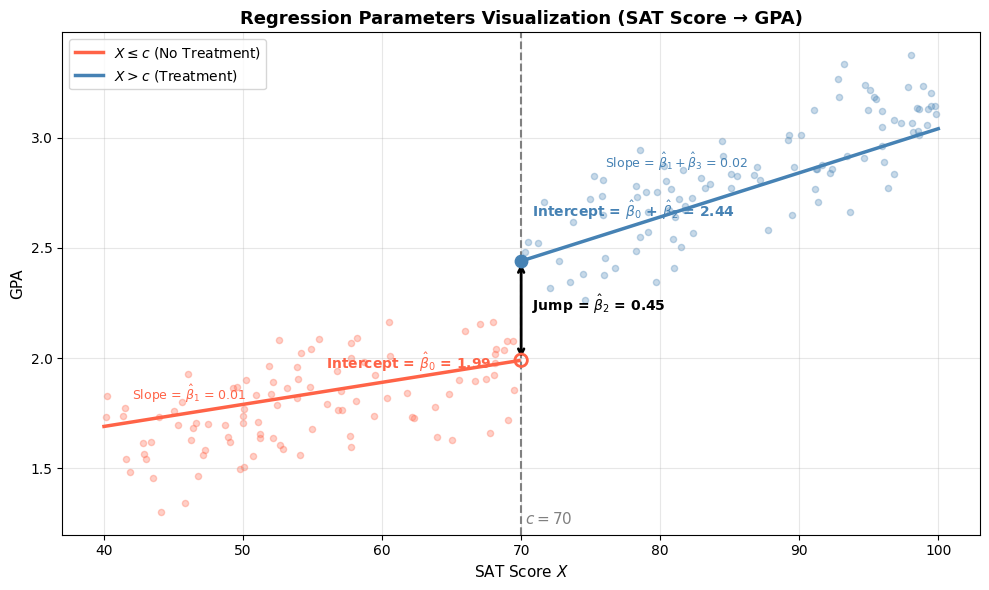

In [34]:
plot_rdd_regression(beta_0=2.0, beta_1=0.015, beta_2=0.5, beta_3=0.005)

There are a few things to focus on when reading this graph.

**Look near the cutoff.** RDD's causal inference holds only just to the left and right of the cutoff (70 points). The fact that students scoring in the 40s and 95s have different GPAs may reflect differences in ability, not the scholarship effect. Only the **jump at the cutoff where the two regression lines fail to meet** has a causal interpretation.

**Slopes may differ.** The regression lines for the treated group (right) and untreated group (left) are allowed to have different slopes. The tendency for GPA to rise with score may vary depending on treatment status. The $\beta_3$ term in the regression equation from Section 5 handles this slope difference.

**A larger jump does not necessarily mean a larger effect.** In Sharp RDD, the jump is the estimated treatment effect directly. In Fuzzy RDD, the jump in Y must be divided by the jump in D. This distinction is covered in the next chapter.

## 7. Example

Let's run a simulation directly. We set the scholarship cutoff at 70 points with a true treatment effect of 0.5 GPA points. We then check whether RDD recovers this effect.

The key steps: fit separate OLS regression lines on the left and right of the cutoff, then estimate the treatment effect as the difference in their intercepts at the cutoff.

In [35]:
n = 500
cutoff = 70
true_effect = 0.5

score = np.random.uniform(40, 100, n)
treated = (score >= cutoff).astype(int)
gpa = (
    2.0
    + 0.015 * (score - cutoff)   # natural effect of running variable
    + true_effect * treated       # scholarship effect
    + np.random.normal(0, 0.25, n)
)

df = pd.DataFrame({
    'score': score,
    'treated': treated,
    'gpa': gpa,
    'score_c': score - cutoff,  # centered at cutoff
})

df.head(8)

,score,treated,gpa,score_c
0,70.055752,1,2.769492,0.055752
1,78.710320,1,2.569921,8.710320
2,97.172015,1,2.588147,27.172015
3,86.065729,1,2.460113,16.065729
4,68.748219,0,1.838636,-1.251781
5,89.957620,1,2.320030,19.957620
6,78.774072,1,2.793793,8.774072
7,40.977001,0,1.911363,-29.022999


In [36]:
# Fit OLS separately on each side of the cutoff
model_left  = smf.ols('gpa ~ score_c', data=df[df['treated'] == 0]).fit()
model_right = smf.ols('gpa ~ score_c', data=df[df['treated'] == 1]).fit()

y_at_c_left  = model_left.predict(pd.DataFrame({'score_c': [0.0]}))[0]
y_at_c_right = model_right.predict(pd.DataFrame({'score_c': [0.0]}))[0]
estimated_effect = y_at_c_right - y_at_c_left

print(f"Left intercept at cutoff:   {y_at_c_left:.4f}")
print(f"Right intercept at cutoff:  {y_at_c_right:.4f}")
print(f"Estimated treatment effect: {estimated_effect:.4f}")
print(f"True treatment effect:      {true_effect}")

Left intercept at cutoff:   2.0218
Right intercept at cutoff:  2.4957
Estimated treatment effect: 0.4739
True treatment effect:      0.5


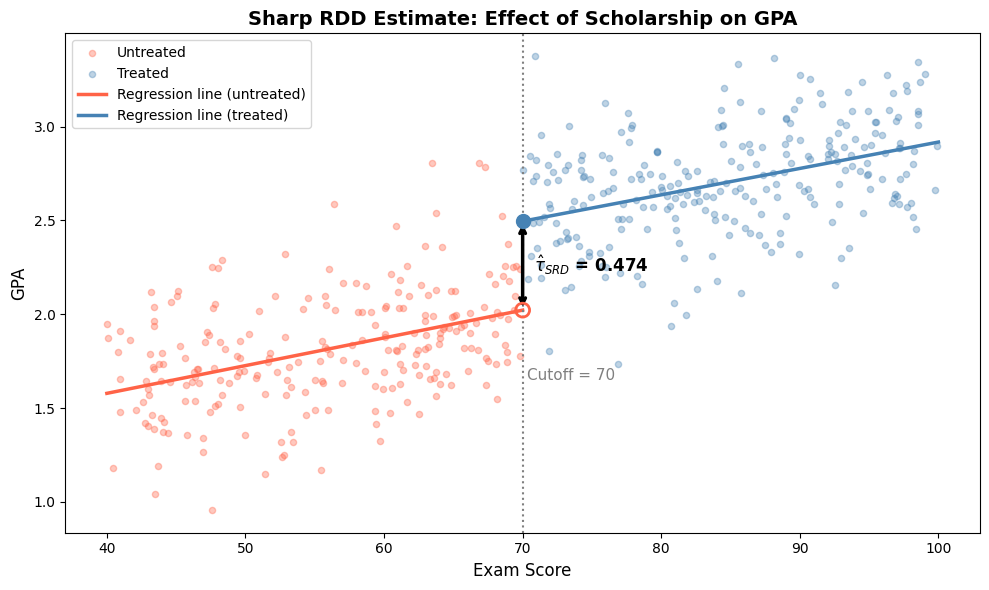

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

left  = df[df['treated'] == 0]
right = df[df['treated'] == 1]

ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.35, s=20, label='Untreated')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.35, s=20, label='Treated')

s_left  = np.linspace(40, cutoff, 100)
s_right = np.linspace(cutoff, 100, 100)
ax.plot(s_left,  model_left.predict(pd.DataFrame({'score_c': s_left  - cutoff})), color='tomato',    linewidth=2.5, label='Regression line (untreated)')
ax.plot(s_right, model_right.predict(pd.DataFrame({'score_c': s_right - cutoff})), color='steelblue', linewidth=2.5, label='Regression line (treated)')

ax.scatter([cutoff], [y_at_c_left],  s=100, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_at_c_right], s=100, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_at_c_right), xytext=(cutoff, y_at_c_left),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))
ax.text(cutoff + 0.8, (y_at_c_left + y_at_c_right) / 2,
        f'$\\hat{{\\tau}}_{{SRD}}$ = {estimated_effect:.3f}',
        fontsize=12, va='center', fontweight='bold')

ax.axvline(cutoff, color='gray', linestyle=':', linewidth=1.5)
ax.text(cutoff + 0.3, 1.65, f'Cutoff = {cutoff}', fontsize=11, color='gray')

ax.set_title('Sharp RDD Estimate: Effect of Scholarship on GPA', fontsize=14, fontweight='bold')
ax.set_xlabel('Exam Score', fontsize=12)
ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## ETC.

Here we review misconceptions that often arise when applying RDD, and the checks that should be run before any analysis.

### Common Misconceptions

"Just look near the cutoff" is correct in spirit, but **how close is close enough** cannot be chosen arbitrarily. Too narrow a window leaves too few observations and inflates variance; too wide a window mixes in units far from the cutoff and introduces bias. This window is the **bandwidth**, and the optimal bandwidth is selected algorithmically (Imbens & Kalyanaraman, 2012).

"RDD is the same as a randomized experiment" is also imprecise. Quasi-randomization holds only *near* the cutoff. RDD does not estimate effects for units far from the cutoff, and external validity may be limited.

### Validity Check: McCrary Density Test

The most important check is whether **manipulation** has occurred. The test proposed by McCrary (2008) is straightforward: verify that the distribution of the running variable is continuous at the cutoff.

If students deliberately aim to score just above 70, or if graders push borderline students over the threshold, there will be an abnormal spike in observations just above the cutoff. Conversely, if units avoid being just above the cutoff, the region just below it will be depleted. Either case appears as a sudden density change near the cutoff in a histogram.

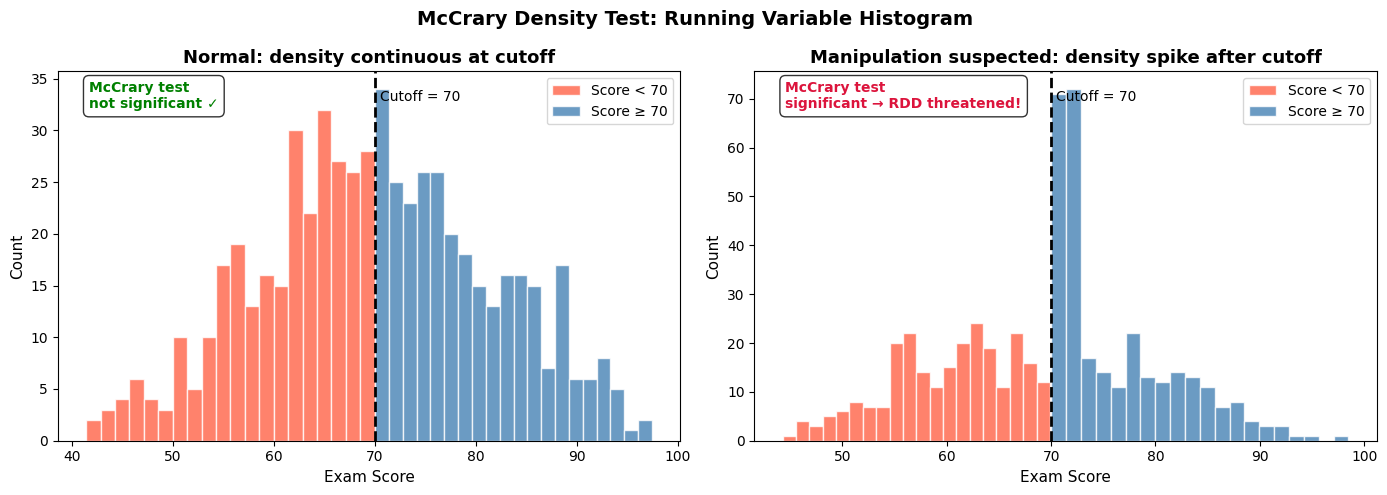

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: No manipulation ──
ax = axes[0]
score_clean = np.random.normal(70, 12, 600)
score_clean = score_clean[(score_clean >= 40) & (score_clean <= 100)]

ax.hist(score_clean[score_clean <  cutoff], bins=20, color='tomato',    edgecolor='white', alpha=0.8, label='Score < 70')
ax.hist(score_clean[score_clean >= cutoff], bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Score ≥ 70')
ax.axvline(cutoff, color='black', linestyle='--', linewidth=2)
ax.text(cutoff + 0.5, ax.get_ylim()[1] * 0.92, f'Cutoff = {cutoff}', fontsize=10, color='black')
ax.set_title('Normal: density continuous at cutoff', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=10)
ax.text(0.05, 0.90, 'McCrary test\nnot significant ✓', transform=ax.transAxes,
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# ── Right: Manipulation suspected ──
ax2 = axes[1]
score_below = np.random.normal(62, 8, 300)
score_below = score_below[(score_below >= 40) & (score_below < cutoff)]
score_above = np.concatenate([
    np.random.normal(78, 7, 200),
    np.random.uniform(70, 73, 120)  # units abnormally clustered just above cutoff
])
score_above = score_above[(score_above >= cutoff) & (score_above <= 100)]

ax2.hist(score_below, bins=20, color='tomato',    edgecolor='white', alpha=0.8, label='Score < 70')
ax2.hist(score_above, bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Score ≥ 70')
ax2.axvline(cutoff, color='black', linestyle='--', linewidth=2)
ax2.text(cutoff + 0.5, ax2.get_ylim()[1] * 0.92, f'Cutoff = {cutoff}', fontsize=10, color='black')
ax2.set_title('Manipulation suspected: density spike after cutoff', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.legend(fontsize=10)
ax2.text(0.05, 0.90, 'McCrary test\nsignificant → RDD threatened!', transform=ax2.transAxes,
         fontsize=10, color='crimson', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.suptitle('McCrary Density Test: Running Variable Histogram', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Other Validity Checks

Beyond the McCrary test, several other checks are important.

**Covariate smoothness test**: run RDD using predetermined covariates (gender, parental income, etc.) as the outcome. If a covariate is discontinuous at the cutoff, it suggests confounding. These checks should show no jump.

**Placebo cutoff test**: run RDD at a fake cutoff (e.g., 60 or 80 points). There should be no discontinuity at a non-threshold value.

**Donut hole test**: exclude observations very close to the cutoff (e.g., within ±2 points) and re-run the analysis. If the estimate changes substantially, something suspicious is happening near the cutoff.

| Test | Purpose | Expected Result |
|------|---------|------------------|
| **McCrary density test** | Check for running variable manipulation | Density continuous at cutoff |
| **Covariate smoothness** | Verify other factors are unrelated to cutoff | Covariate jump = 0 |
| **Placebo cutoff** | No discontinuity at non-threshold values | Effect at fake cutoff = 0 |
| **Donut hole** | Robustness to near-cutoff manipulation | Estimates stable after exclusion |

## References

- [Causal Inference for the Brave and True (Youtube)](https://www.youtube.com/watch?v=8SIoMJTmO3A)
- Imbens, G. W., & Lemieux, T. (2008). Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615–635.
- McCrary, J. (2008). Manipulation of the running variable in the regression discontinuity design: A density test. *Journal of Econometrics*, 142(2), 698–714.
- Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019). *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.